# Class 12: The Building Blocks of LLMs

Today we will:
1. Understand **word embeddings**: how machines turn text into numbers
2. See how **transformers** process entire sequences with attention
3. Trace the **three training phases** of an LLM: pre-training → fine-tuning → RLHF
4. Watch a **foundation model for tabular data** beat our best Class 5 model in 3 lines

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Display settings
pd.set_option('display.precision', 3)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## From Pixels to Words: The Embedding Problem

### The problem: How do you give text to a neural network?

- In Class 9, we fed **784 pixel values** into a neural network. Each pixel is already a number.
- But what if your input is: *"The cat sat on the mat"*?
- Neural networks take **numbers** as input (vectors of floats)
- Text is **discrete** — words are symbols, not numbers
- We need a way to convert words → vectors

### Naive approach: One-hot encoding

- Vocabulary of V words → each word gets a V-dimensional vector with a single 1
- Problems:
  - **Huge**: vocabulary of 50,000 words → 50,000-dimensional vectors
  - **No relationships**: distance between "cat" and "dog" = distance between "cat" and "refrigerator"
  - Recall the **curse of dimensionality** from Class 1!

In [23]:
# One-hot encoding example
vocab = ['king', 'queen', 'man', 'woman', 'cat', 'dog', 'car', 'bicycle']
n_vocab = len(vocab)

one_hot = np.eye(n_vocab)
one_hot_df = pd.DataFrame(one_hot, index=vocab, columns=vocab).astype(int)

print("One-hot encoding:")
one_hot_df

One-hot encoding:


,king,queen,man,woman,cat,dog,car,bicycle
king,1,0,0,0,0,0,0,0
queen,0,1,0,0,0,0,0,0
man,0,0,1,0,0,0,0,0
woman,0,0,0,1,0,0,0,0
cat,0,0,0,0,1,0,0,0
dog,0,0,0,0,0,1,0,0
car,0,0,0,0,0,0,1,0
bicycle,0,0,0,0,0,0,0,1


In [24]:
# Distances between one-hot vectors — all equidistant!
from scipy.spatial.distance import pdist, squareform

distances = squareform(pdist(one_hot, metric='euclidean'))
dist_df = pd.DataFrame(distances, index=vocab, columns=vocab)

print("Euclidean distances (one-hot):")
print(f"  king ↔ queen: {dist_df.loc['king', 'queen']:.3f}")
print(f"  king ↔ car:   {dist_df.loc['king', 'car']:.3f}")
print(f"  cat  ↔ dog:   {dist_df.loc['cat', 'dog']:.3f}")
print(f"  cat  ↔ car:   {dist_df.loc['cat', 'car']:.3f}")
print("\n→ Everything is equidistant. One-hot tells us nothing about meaning.")

Euclidean distances (one-hot):
  king ↔ queen: 1.414
  king ↔ car:   1.414
  cat  ↔ dog:   1.414
  cat  ↔ car:   1.414

→ Everything is equidistant. One-hot tells us nothing about meaning.


### The solution: Dense embeddings

- Map each word to a **low-dimensional** vector (e.g., 100-300 dimensions instead of 50,000)
- **Key insight**: Words that appear in similar contexts should have similar vectors
- "You shall know a word by the company it keeps" — J.R. Firth (1957)

### Word2Vec: Learning word vectors from context

**Skip-gram idea:** Given a word, predict the surrounding words.

Example sentence: *"The cat sat on the mat"*
- Given "cat" → predict "the", "sat"
- Given "sat" → predict "cat", "on"

Words that predict similar contexts → get similar vectors.

- "dog" and "cat" both appear near "the", "sat", "ran", "pet" → close in embedding space
- "car" appears near "drive", "road", "engine" → far from "cat" in embedding space

**This is self-supervised learning**: the labels (the neighboring words) come for free from the data — you don't need to manually annotate anything. "The text supervises itself."

The embedding is the learned weights of this prediction network — **same idea as the hidden representations we visualized for MNIST digits in Class 9**.

### Exploring pre-trained word embeddings (Word2Vec)

- Training embeddings from scratch requires billions of words
- We'll use **pre-trained Word2Vec** embeddings from Google News
- Trained with a neural network (skip-gram) on ~100 billion words from Google News articles
- Each word → 300-dimensional vector (we use the top 60,000 most common words)
- **Same idea as Class 9**: the embeddings are the learned hidden layer weights of the prediction network

In [25]:
# Load pre-trained Word2Vec embeddings (300d, top 60K words from Google News)
# Original model: https://code.google.com/archive/p/word2vec/ (Mikolov et al., 2013)
# We use a trimmed version (top 60K words) for speed

import os

w2v_path = '../data/word2vec/word2vec-google-news-60k-300d.txt'

def load_word2vec(path, max_words=60000):
    """Load Word2Vec embeddings into a dictionary."""
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= max_words:
                break
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vector
    return embeddings

# Load embeddings
if os.path.exists(w2v_path):
    w2v = load_word2vec(w2v_path)
    print(f"Loaded {len(w2v)} word vectors of dimension {len(list(w2v.values())[0])}")
else:
    print(f"Word2Vec file not found at {w2v_path}.")
    print("Ask instructor for the file or generate with:")
    print("  import gensim.downloader as api")
    print("  model = api.load('word2vec-google-news-300')")
    w2v = None

Loaded 60000 word vectors of dimension 300


In [26]:
# What does a word vector look like?
if w2v:
    word = 'king'
    vec = w2v[word]
    print(f"Vector for '{word}' (first 10 dimensions): {vec[:10]}")
    print(f"Dimension: {vec.shape[0]}")
    print(f"Norm: {np.linalg.norm(vec):.3f}")

Vector for 'king' (first 10 dimensions): [ 0.125977  0.029785  0.008606  0.139648 -0.025635 -0.036133  0.111816
 -0.198242  0.05127   0.363281]
Dimension: 300
Norm: 2.902


### Measuring word similarity with cosine similarity

- Euclidean distance is affected by vector magnitude
- **Cosine similarity** measures the angle between vectors:

$$\text{cos}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|}$$

- Range: -1 (opposite) to +1 (identical direction)
- Standard for comparing embeddings

In [27]:
def word_similarity(word1, word2, embeddings):
    """Compute cosine similarity between two words."""
    v1 = embeddings[word1].reshape(1, -1)
    v2 = embeddings[word2].reshape(1, -1)
    return cosine_similarity(v1, v2)[0, 0]

def most_similar(word, embeddings, top_n=10):
    """Find the most similar words to a given word."""
    vec = embeddings[word].reshape(1, -1)
    all_words = list(embeddings.keys())
    all_vecs = np.array([embeddings[w] for w in all_words])
    sims = cosine_similarity(vec, all_vecs)[0]
    top_idx = np.argsort(sims)[::-1][1:top_n+1]  # skip the word itself
    return [(all_words[i], sims[i]) for i in top_idx]

# Note: Word2Vec Google News uses capitalized proper nouns (Paris, France, etc.)
# Common words are lowercase (king, cat, etc.)

In [28]:
# Compare meaningful vs arbitrary word pairs
if w2v:
    pairs = [
        ('king', 'queen'),
        ('king', 'man'),
        ('king', 'car'),
        ('cat', 'dog'),
        ('cat', 'car'),
        ('Paris', 'France'),
        ('Tokyo', 'Japan'),
        ('good', 'great'),
        ('good', 'bad'),
    ]
    
    print("Cosine similarities:")
    print("-" * 35)
    for w1, w2 in pairs:
        sim = word_similarity(w1, w2, w2v)
        print(f"  {w1:>8s} ↔ {w2:<8s}: {sim:.3f}")

Cosine similarities:
-----------------------------------
      king ↔ queen   : 0.651
      king ↔ man     : 0.229
      king ↔ car     : 0.062
       cat ↔ dog     : 0.761
       cat ↔ car     : 0.215
     Paris ↔ France  : 0.633
     Tokyo ↔ Japan   : 0.700
      good ↔ great   : 0.729
      good ↔ bad     : 0.719


- Related words (king-queen, cat-dog, Paris-France) have high similarity
- Unrelated words (king-car, cat-car) have low similarity
- Interestingly, "good" and "bad" are somewhat similar — they appear in similar contexts! (adjectives describing quality)
- Note: Word2Vec trained on Google News uses **capitalized** proper nouns (Paris, France) — that's how they appear in news articles

In [29]:
# Most similar words
if w2v:
    for word in ['king', 'python', 'apple', 'Apple', 'Vienna']:
        similar = most_similar(word, w2v, top_n=8)
        words_str = ', '.join([f"{w} ({s:.2f})" for w, s in similar])
        print(f"\nMost similar to '{word}':")
        print(f"  {words_str}")


Most similar to 'king':
  kings (0.71), queen (0.65), monarch (0.64), crown_prince (0.62), prince (0.62), ruler (0.58), princes (0.56), throne (0.54)

Most similar to 'python':
  snake (0.66), crocodile (0.66), alligator (0.64), reptile (0.64), lizard (0.60), gator (0.57), leopard (0.56), snakes (0.53)

Most similar to 'apple':
  apples (0.72), pear (0.65), fruit (0.64), berry (0.63), pears (0.61), strawberry (0.61), peach (0.60), potato (0.60)

Most similar to 'Apple':
  Apple_AAPL (0.75), Apple_Computer (0.71), iPhone (0.69), Steve_Jobs (0.68), iPad (0.66), Apple_iPad (0.62), iPhones (0.62), Nexus_One (0.62)

Most similar to 'Vienna':
  Vienna_Austria (0.75), Berlin (0.60), Budapest (0.59), Prague (0.56), Austria (0.56), Warsaw (0.56), Austrian (0.55), Bucharest (0.55)


### Word analogies: The famous king - man + woman = queen

- Embeddings capture **linear relationships** between concepts
- The vector from "man" to "woman" is similar to the vector from "king" to "queen"
- This means: $\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$

In [30]:
def analogy(a, b, c, embeddings, top_n=5):
    """Solve: a is to b as c is to ???
    Computes: b - a + c and finds nearest word."""
    vec = embeddings[b] - embeddings[a] + embeddings[c]
    vec = vec.reshape(1, -1)
    
    exclude = {a, b, c}
    all_words = [w for w in embeddings if w not in exclude]
    all_vecs = np.array([embeddings[w] for w in all_words])
    
    sims = cosine_similarity(vec, all_vecs)[0]
    top_idx = np.argsort(sims)[::-1][:top_n]
    return [(all_words[i], sims[i]) for i in top_idx]

In [31]:
# Classic analogies
if w2v:
    analogies = [
        ('man', 'king', 'woman', 'queen'),           # gender
        ('Paris', 'France', 'Tokyo', 'Japan'),        # capital-country
        ('slow', 'slower', 'fast', 'faster'),         # comparative
        ('big', 'biggest', 'small', 'smallest'),      # superlative
    ]
    
    for a, b, c, expected in analogies:
        results = analogy(a, b, c, w2v, top_n=3)
        top_word = results[0][0]
        match = '✓' if top_word == expected else '✗'
        print(f"  {a} → {b} as {c} → ? ")
        print(f"    Expected: {expected}, Got: {top_word} {match}")
        print(f"    Top 3: {', '.join([f'{w} ({s:.2f})' for w, s in results])}")
        print()

  man → king as woman → ? 
    Expected: queen, Got: queen ✓
    Top 3: queen (0.73), monarch (0.65), princess (0.62)

  Paris → France as Tokyo → ? 
    Expected: Japan, Got: Japan ✓
    Top 3: Japan (0.83), Japanese (0.68), South_Korea (0.61)

  slow → slower as fast → ? 
    Expected: faster, Got: faster ✓
    Top 3: faster (0.72), quicker (0.61), fastest (0.56)

  big → biggest as small → ? 
    Expected: smallest, Got: largest ✗
    Top 3: largest (0.68), smallest (0.65), tiny (0.50)



### Visualizing word embeddings with PCA

- 50 dimensions → 2D using PCA (Class 2!)
- Semantic clusters should be visible

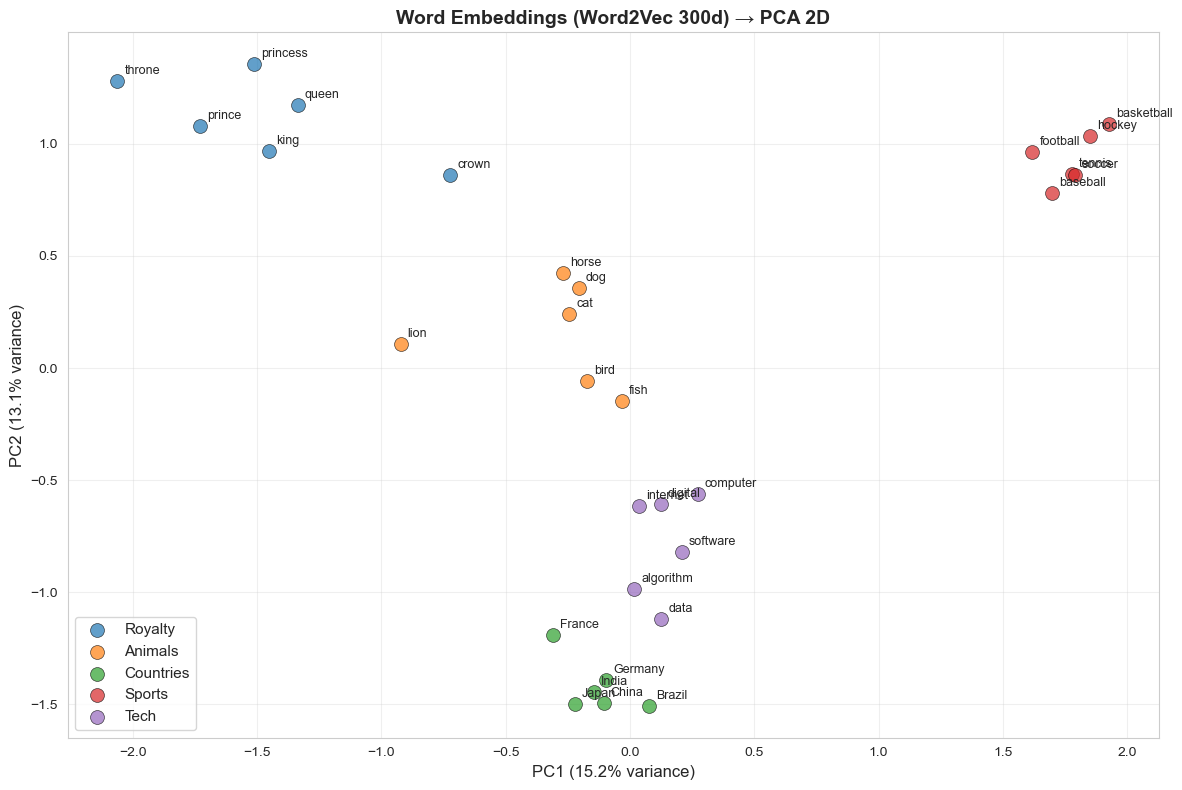

In [32]:
# Select themed word groups and project with PCA
if w2v:
    word_groups = {
        'Royalty': ['king', 'queen', 'prince', 'princess', 'throne', 'crown'],
        'Animals': ['cat', 'dog', 'bird', 'fish', 'horse', 'lion'],
        'Countries': ['France', 'Germany', 'Japan', 'China', 'Brazil', 'India'],
        'Sports': ['football', 'basketball', 'tennis', 'baseball', 'soccer', 'hockey'],
        'Tech': ['computer', 'software', 'internet', 'algorithm', 'data', 'digital'],
    }
    
    all_words_viz = []
    all_labels = []
    all_vecs_viz = []
    
    for group, words in word_groups.items():
        for w in words:
            if w in w2v:
                all_words_viz.append(w)
                all_labels.append(group)
                all_vecs_viz.append(w2v[w])
    
    vecs_matrix = np.array(all_vecs_viz)
    
    # PCA to 2D
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vecs_matrix)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for group in word_groups:
        mask = [l == group for l in all_labels]
        ax.scatter(coords[mask, 0], coords[mask, 1], label=group, s=100, alpha=0.7, edgecolors='k', linewidth=0.5)
    
    for i, word in enumerate(all_words_viz):
        ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9,
                   xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    ax.set_title('Word Embeddings (Word2Vec 300d) → PCA 2D', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

- Words cluster by semantic category — **no one told the model that France and Germany are countries**. It learned this from how they appear in sentences.
- This is exactly the **manifold hypothesis** from Class 9: meaningful concepts live on a low-dimensional surface
- PCA (Class 2) reveals the structure learned by the embedding model

### Visualizing analogy relationships

- The gender direction (king→queen, man→woman) should be consistent

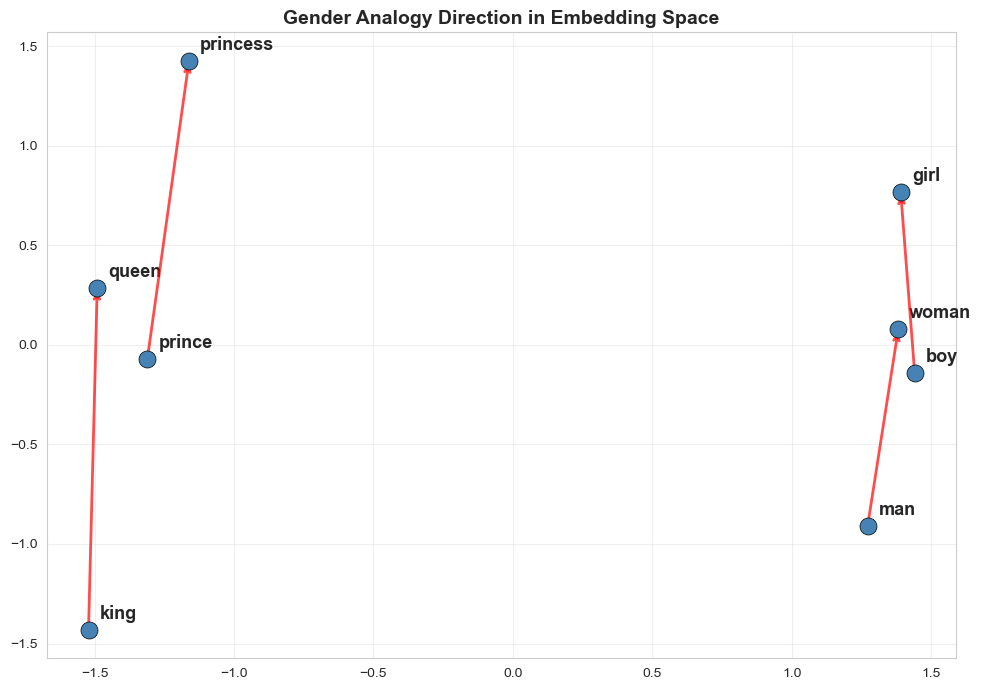

In [33]:
# Visualize analogy vectors
if w2v:
    analogy_words = ['king', 'queen', 'man', 'woman', 'prince', 'princess', 'boy', 'girl']
    analogy_vecs = np.array([w2v[w] for w in analogy_words])
    
    pca_analogy = PCA(n_components=2, random_state=42)
    coords_a = pca_analogy.fit_transform(analogy_vecs)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Plot points
    ax.scatter(coords_a[:, 0], coords_a[:, 1], s=150, c='steelblue', edgecolors='k', linewidth=0.5, zorder=5)
    
    for i, word in enumerate(analogy_words):
        ax.annotate(word, (coords_a[i, 0], coords_a[i, 1]), fontsize=13, fontweight='bold',
                   xytext=(8, 8), textcoords='offset points')
    
    # Draw arrows for male→female pairs
    pairs_to_draw = [(0, 1), (2, 3), (4, 5), (6, 7)]  # king→queen, man→woman, etc.
    for i, j in pairs_to_draw:
        ax.annotate('', xy=coords_a[j], xytext=coords_a[i],
                   arrowprops=dict(arrowstyle='->', color='red', lw=2, alpha=0.7))
    
    ax.set_title('Gender Analogy Direction in Embedding Space', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

- All red arrows point in roughly the same direction: the "gender" direction
- Embeddings learn **systematic relationships** as linear directions in vector space
- Other directions encode other relationships: singular/plural, country/capital, tense

### From word embeddings to sentence embeddings

- Word embeddings map *individual words* to vectors
- But we often need to compare *sentences* or *documents*
- **Simple approach**: average the word vectors in a sentence — let's try it

In [34]:
def sentence_embedding(text, embeddings, dim=300):
    """Simple sentence embedding: average of word vectors."""
    words = text.lower().split()
    vecs = [embeddings[w] for w in words if w in embeddings]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

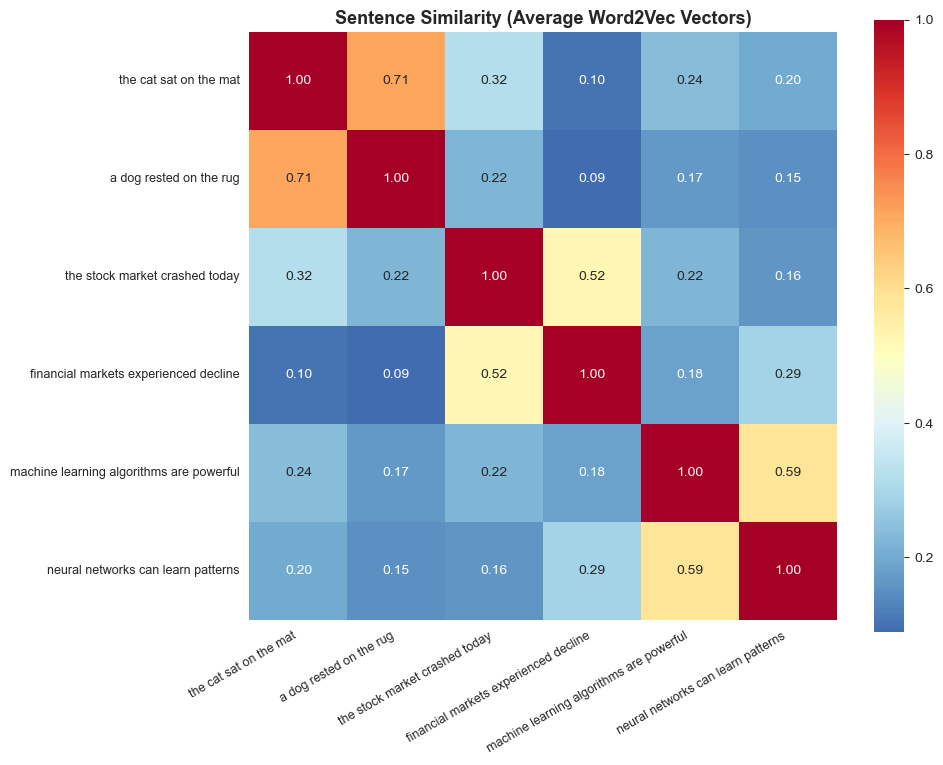

In [35]:
# Compare sentence similarities
if w2v:
    sentences = [
        "the cat sat on the mat",
        "a dog rested on the rug",
        "the stock market crashed today",
        "financial markets experienced decline",
        "machine learning algorithms are powerful",
        "neural networks can learn patterns",
    ]
    
    sent_vecs = np.array([sentence_embedding(s, w2v) for s in sentences])
    sim_matrix = cosine_similarity(sent_vecs)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(sim_matrix, xticklabels=sentences, yticklabels=sentences,
                annot=True, fmt='.2f', cmap='RdYlBu_r', center=0.5,
                ax=ax, square=True)
    ax.set_title('Sentence Similarity (Average Word2Vec Vectors)', fontsize=13, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

- Semantically similar sentences (cat-dog, market-financial, ML-NN) have higher cosine similarity
- But averaging word vectors is crude — it ignores word order ("dog bites man" = "man bites dog")
- **Worse**: every word gets the same vector regardless of context
  - "The ML **model** performed well" and "The fashion **model** walked the runway" → **same** vector for "model"!
- Modern models (transformers) solve both problems — let's see how

### Live demo: Input embeddings vs. contextual embeddings

We'll use a pre-trained **Sentence Transformer** (MiniLM — a small model with 6 transformer layers) to show the difference:

1. **Tokenization**: how text gets split into tokens
2. **Input embeddings** (context-free): same vector for "model" regardless of surrounding words
3. **After the transformer** (contextual): different vectors depending on context

In [36]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from sentence_transformers import SentenceTransformer
import torch

# Load a small, fast transformer model (6 layers, 384-dimensional output)
st_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')
tokenizer = st_model.tokenizer
transformer = st_model[0].auto_model.cpu()

print(f"Model: all-MiniLM-L6-v2")
print(f"Transformer layers: 6")
print(f"Output embedding dimension: {st_model.get_sentence_embedding_dimension()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14582.73it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: all-MiniLM-L6-v2
Transformer layers: 6
Output embedding dimension: 384


In [37]:
# Step 1: Tokenization — how text gets split into tokens
s1 = "The ML model performed well"
s2 = "The fashion model walked the runway"

enc1 = tokenizer(s1, return_tensors='pt')
enc2 = tokenizer(s2, return_tensors='pt')

tokens1 = tokenizer.convert_ids_to_tokens(enc1['input_ids'][0])
tokens2 = tokenizer.convert_ids_to_tokens(enc2['input_ids'][0])

print(f'Sentence 1: "{s1}"')
print(f'  Tokens: {tokens1}')
print(f'\nSentence 2: "{s2}"')
print(f'  Tokens: {tokens2}')
print(f'\n→ Each token is a chunk of text the model treats as a unit.')
print(f'  [CLS] and [SEP] are special start/end markers.')

Sentence 1: "The ML model performed well"
  Tokens: ['[CLS]', 'the', 'ml', 'model', 'performed', 'well', '[SEP]']

Sentence 2: "The fashion model walked the runway"
  Tokens: ['[CLS]', 'the', 'fashion', 'model', 'walked', 'the', 'runway', '[SEP]']

→ Each token is a chunk of text the model treats as a unit.
  [CLS] and [SEP] are special start/end markers.


In [38]:
# Step 2: Input embeddings are CONTEXT-FREE (like Word2Vec)
# The embedding lookup table gives the same vector for "model" regardless of context

embed_layer = transformer.embeddings.word_embeddings
model_token_id = tokenizer.convert_tokens_to_ids('model')

# Get the raw input embedding for "model" — it's the same in both sentences
input_emb = embed_layer(torch.tensor([model_token_id])).detach().numpy()

print("Input embeddings for 'model':")
print(f"  Token ID: {model_token_id}")
print(f"  Vector (first 8 dims): {input_emb[0, :8].round(3)}")
print(f"\n  Cosine similarity between 'model' in sentence 1 vs sentence 2: 1.000")
print(f"\n→ Same lookup vector regardless of context — this is like Word2Vec.")
print(f"  The model doesn't know if 'model' means ML model or fashion model yet.")

Input embeddings for 'model':
  Token ID: 2944
  Vector (first 8 dims): [-0.04  -0.016  0.001 -0.016  0.014 -0.004 -0.072  0.05 ]

  Cosine similarity between 'model' in sentence 1 vs sentence 2: 1.000

→ Same lookup vector regardless of context — this is like Word2Vec.
  The model doesn't know if 'model' means ML model or fashion model yet.


In [39]:
# Step 3: After the transformer, CONTEXT CHANGES EVERYTHING
# The 6 transformer layers process the full sequence — each token "looks at" every other token

with torch.no_grad():
    out1 = transformer(**enc1)
    out2 = transformer(**enc2)

# Find position of 'model' in each tokenized sentence
pos1 = tokens1.index('model')
pos2 = tokens2.index('model')

# Extract the contextualized embedding for 'model' from each sentence
ctx_emb1 = out1.last_hidden_state[0, pos1].numpy().reshape(1, -1)
ctx_emb2 = out2.last_hidden_state[0, pos2].numpy().reshape(1, -1)

ctx_sim = cosine_similarity(ctx_emb1, ctx_emb2)[0, 0]

print("After 6 transformer layers:")
print(f'  "The ML model performed well"')
print(f'  "The fashion model walked the runway"')
print(f'\n  Cosine similarity of "model" representations: {ctx_sim:.3f}')

# Now compare full sentence embeddings
s3 = "The neural network achieved high accuracy"
sent_embs = st_model.encode([s1, s2, s3])

sim_12 = cosine_similarity(sent_embs[0:1], sent_embs[1:2])[0, 0]
sim_13 = cosine_similarity(sent_embs[0:1], sent_embs[2:3])[0, 0]

print(f'\nFull sentence embeddings:')
print(f'  "ML model" vs "fashion model":           {sim_12:.3f} (different meanings → far apart)')
print(f'  "ML model" vs "neural network accuracy":  {sim_13:.3f} (similar meanings → closer)')
print(f'\n→ The transformer layers add context. Same word in, different representation out.')
print(f'  This is the key upgrade from Word2Vec/GloVe to modern models.')

After 6 transformer layers:
  "The ML model performed well"
  "The fashion model walked the runway"

  Cosine similarity of "model" representations: 0.732

Full sentence embeddings:
  "ML model" vs "fashion model":           0.272 (different meanings → far apart)
  "ML model" vs "neural network accuracy":  0.462 (similar meanings → closer)

→ The transformer layers add context. Same word in, different representation out.
  This is the key upgrade from Word2Vec/GloVe to modern models.


**Connection to Class 9**: In Class 9, raw pixels couldn't distinguish similar digits, but the hidden layer representations could. Here, raw token embeddings can't distinguish word meanings, but the transformer output can. **Same principle — learned representations capture what matters.**

### Practical application: Semantic search with embeddings

Embeddings power **semantic search**: find relevant documents by meaning, not just keyword matching. This is how vector databases (Pinecone, Weaviate, ChromaDB) work — and how RAG (Retrieval-Augmented Generation) feeds context to LLMs.

In [40]:
# Semantic search: find relevant documents by meaning
documents = [
    "PCA reduces dimensionality by finding directions of maximum variance",
    "K-means clustering groups data points into k clusters based on distance",
    "Neural networks learn non-linear transformations through hidden layers",
    "Lasso regression adds L1 penalty to shrink coefficients toward zero",
    "Transfer learning reuses features from models trained on large datasets",
    "The bias-variance tradeoff balances model complexity against stability",
    "Decision trees split data using feature thresholds to make predictions",
    "CNNs use convolutional filters to detect spatial patterns in images",
    "Random forests combine many decision trees to reduce overfitting",
    "Gradient descent optimizes model parameters by following the loss gradient",
]

doc_embeddings = st_model.encode(documents)

def search(query, doc_embeddings, documents, top_k=3):
    """Semantic search: find most relevant documents for a query."""
    q_emb = st_model.encode([query])
    sims = cosine_similarity(q_emb, doc_embeddings)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    print(f"Query: '{query}'")
    print("-" * 60)
    for i in top_idx:
        print(f"  [{sims[i]:.3f}] {documents[i]}")
    print()

# The query doesn't need to share exact words with the documents!
search("how to handle high-dimensional data", doc_embeddings, documents)
search("preventing overfitting", doc_embeddings, documents)
search("image recognition", doc_embeddings, documents)

Query: 'how to handle high-dimensional data'
------------------------------------------------------------
  [0.431] PCA reduces dimensionality by finding directions of maximum variance
  [0.344] Transfer learning reuses features from models trained on large datasets
  [0.289] Decision trees split data using feature thresholds to make predictions

Query: 'preventing overfitting'
------------------------------------------------------------
  [0.509] Random forests combine many decision trees to reduce overfitting
  [0.378] Transfer learning reuses features from models trained on large datasets
  [0.273] Decision trees split data using feature thresholds to make predictions

Query: 'image recognition'
------------------------------------------------------------
  [0.444] CNNs use convolutional filters to detect spatial patterns in images
  [0.281] Neural networks learn non-linear transformations through hidden layers
  [0.230] Transfer learning reuses features from models trained on large

### Connections to the course

- **Class 2 (PCA)**: Embeddings are learned dimensionality reduction — but nonlinear and task-aware
- **Class 9 (manifold hypothesis)**: Word embeddings are the NLP manifold — "words live on a low-dimensional surface in meaning-space, just like digits live on a manifold in pixel-space"
- **Class 10 (transfer learning)**: Pre-trained embeddings are the NLP equivalent of ImageNet features — someone trained on billions of words, you reuse the representations
- **Data Engineering (vector databases)**: You can store these embeddings and search by similarity — find similar products, similar movies, similar documents. If you can embed it, you can build a recommender system.

## The Transformer: Same Procedure, Much More Complex Architecture

### What transformers changed

- Before transformers, the standard for text was **Recurrent Neural Networks (RNNs)**: process tokens one by one, left to right, compressing everything seen so far into a single summary vector
- **Problem**: by the end of a long sentence, early words are mostly forgotten — the summary vector can only hold so much
- **The key innovation**: transformers don't try to remember — they just **look back at the original tokens** whenever needed. Every token can directly access every other token in a single step. The network learns which tokens are relevant to each other — no sequential processing, no forgetting.
- This is the architectural breakthrough behind GPT, BERT, and all modern LLMs
- **Connection to CNNs (Class 9)**: CNNs process local patches of an image. Transformers process the entire sequence at once. Both learn relevant patterns automatically — just different architectures for different data types.

### How text generation works — token by token

Here's something surprising: **ChatGPT generates text one token at a time.**

1. Input: "The capital of Hungary is" → forward pass through entire network → output: probability distribution over ~100K tokens
2. Model picks "Budapest" (highest probability)
3. Input becomes: "The capital of Hungary is Budapest" → forward pass → picks "."
4. Repeat until stop token

Every time you see ChatGPT "typing" word by word, that's not a UI effect — **the model genuinely doesn't know word 2 until it has generated word 1**. Each token requires a full forward pass through the network.

Why it's still fast: massively parallel hardware (GPUs with thousands of cores doing matrix multiplications), plus caching of previous computations so each new token doesn't reprocess the entire history.

## Training an LLM: From Raw Text to ChatGPT

### Phase 1: Pre-training — predict the next token

The training objective is remarkably simple: **given all previous tokens, predict the next one.**

The loss is **cross-entropy — exactly the same as MNIST in Class 9.** MNIST: probability distribution over 10 digit classes. LLM: probability distribution over ~100K tokens. Same math, different scale.

**One training step:**
1. Take a sentence from the training data: "The capital of Hungary is Budapest"
2. Forward pass: model sees "The capital of Hungary is" → predicts probability distribution over 100K tokens
3. The correct answer is "Budapest" (token #4523). Loss = how much probability was *not* on "Budapest"
4. Backpropagation: gradients flow backwards through every transformer layer, all the way back to the embedding table. **Everything gets updated** — transformer weights AND the embedding lookup table
5. Repeat on **billions** of sentences

"But can't a sentence continue in multiple valid ways?" Yes — and over billions of examples, the model learns a **probability distribution**. "Budapest" gets 0.82, "Vienna" gets 0.03, "Prague" gets 0.02. The model doesn't learn hard rules; it learns which continuations are likely.

**This is self-supervised learning**: the labels (the actual next word) come for free from the data. No human annotation needed. "The text supervises itself — this is how you can train on the entire internet."

**This is also why the embeddings become good**: the model can't predict well without understanding what words mean. Good embeddings emerge as a by-product of learning to predict, just like good hidden representations emerged in our MNIST network from learning to classify.

### Phase 2: Fine-tuning — from word predictor to assistant

Pre-training produces a model that's great at predicting text. But that's not the same as being *useful*.

A pure next-word predictor given "What is 2+2?" might continue with "This question appeared on a worksheet..." — it's predicting internet text, not answering questions.

**Supervised fine-tuning (SFT)**: train on thousands of curated conversations:
- User: "What is 2+2?" → Assistant: "4"
- User: "Explain photosynthesis simply" → Assistant: "Plants use sunlight..."

Same training process (next-token prediction + backprop), just on *desired assistant behavior* instead of raw internet text. The model already "knows" everything from pre-training; fine-tuning teaches it the *format* of being helpful.

**Same pattern as Class 10**:
- Class 10: ResNet (trained on ImageNet) → fine-tune on hot dog images
- LLMs: GPT (trained on internet text) → fine-tune on assistant conversations

### Phase 3: RLHF — learning to be good at being an assistant

Fine-tuning gets you 80% of the way. But there are many valid answers to "Explain quantum physics" — which one is *best*? You can't write a loss function for "helpful, harmless, and honest."

1. The model generates **multiple responses** to the same prompt
2. **Human evaluators rank them** — "response A is better than response B" (not "this is correct" — just preferences)
3. Train a **reward model** (a separate neural network) that learns to predict which responses humans prefer
4. Use the reward model as the **reward signal** to further train the LLM via RL

**This is the bandit game from Class 11**: the model generates a response (action), gets a reward score (from the reward model), and updates to generate better responses. Except instead of choosing between 5 arms, it's choosing between billions of possible sentences.

**All three paradigms converge**: unsupervised pre-training + supervised fine-tuning + reinforcement learning from human feedback.

### The iceberg — three phases at different scales

```
          ┌─────────────────────┐
          │  Fine-tuning (SFT)  │  ← thousands of conversations, hours
          ├─────────────────────┤
          │       RLHF          │  ← thousands of comparisons, hours
  ~~~~~~~~╪═════════════════════╪~~~~~~~~  waterline
          │                     │
          │                     │
          │    Pre-training     │  ← billions of tokens, months,
          │                     │     millions of dollars
          │                     │
          │                     │
          └─────────────────────┘
```

The vast majority of the learning happens underwater. Pre-training builds the foundation — understanding of language, facts, reasoning. Fine-tuning and RLHF are small adjustments that steer this massive ship.

You don't train ChatGPT from scratch to be helpful. You train a next-word predictor on the internet (months, millions of dollars), fine-tune it on conversations (hours), then align it with human preferences (hours). The ratio is roughly **1,000,000 : 1,000 : 1,000** in training data.

## Wrap-up

### Foundation models for tabular data

We showed foundation models for images (ResNet, Class 10) and text (GPT, today). The same idea is coming to the data you work with most — **tabular data**.

**TabPFN**: a transformer pre-trained on millions of *synthetic* datasets. It learned "how to do regression" as a general skill. You hand it your data, it predicts — no hyperparameter tuning needed.

### But wait — how do you pre-train without real data?

For LLMs, pre-training data is the internet. For ResNet, it was ImageNet. But for tabular data, there's no "internet of datasets." So the TabPFN authors asked: **what structural properties do real tabular datasets tend to have?**

Their answer: design a *recipe* (a **prior**) that can generate infinite synthetic datasets with realistic properties:

1. **Start with a random neural network** — sample a random number of layers and nodes (like an MLP)
2. **Drop random edges** → this creates a sparse directed graph (a **structural causal model**) where some features cause others through hidden variables
3. **Sample random weights and activation functions** (Tanh, ReLU, etc.)
4. **Pick which nodes are "observed"** — some become your features (X), one becomes the target (y). The rest are unobserved latent variables — just like in real data, not everything is measured
5. **Add noise** at every node and propagate through the graph → out comes a synthetic dataset

The key structural assumptions baked into this recipe:
- Features have **causal relationships** (some cause others)
- There are **hidden confounders** (unobserved variables)
- **Simpler structures are more common** (Occam's razor — few layers/nodes favored)
- Features have **varying importance** and can be **correlated in blocks**

### Neural networks all the way down

Notice something: **both the data generation and the model training exploit neural network architectures.**

- **Data generation**: each synthetic dataset is the output of a **random sparse neural network** (the structural causal model is implemented as an MLP with dropped edges)
- **Model training**: the model learning to predict on these datasets is a **transformer** — also a neural network

So it's a transformer learning to do inference on data generated by random neural networks.

**Connection to Class 9**: In Class 9, we saw that a neural network's hidden layers learn meaningful representations of MNIST digits. TabPFN flips that insight around — if neural networks are good at *capturing* the structure of real-world data, then random neural networks should be a good *prior* for what data-generating processes look like.

Let's test it on the **bike share demand** dataset from Class 5, same features, same train/test split.

### How TabPFN makes predictions — no fine-tuning needed

Here's the surprising part: **TabPFN doesn't fine-tune on your data at all.** It works fundamentally differently from ResNet or GPT transfer learning.

When you call `tabpfn.fit(X_train, y_train)`, **nothing happens** — it just stores your data. No gradient updates, no parameter changes. The transformer weights are frozen forever after pre-training.

When you call `tabpfn.predict(X_test)`, here's what happens:

1. **Pack everything into one input**: the entire training set (X_train, y_train) AND the test points X_test get concatenated into a single sequence — like tokens in a sentence
2. **One forward pass** through the transformer: attention lets each test point "look at" all training points and figure out which ones are relevant
3. **Out comes the prediction** for every test point simultaneously

It's literally: `prediction = transformer([X_train, y_train, X_test])`

**This is in-context learning** — the same thing ChatGPT does when you write:

> "Paris → France, Tokyo → Japan, Berlin → ?"

ChatGPT doesn't retrain its weights. It uses the examples *in the prompt* to figure out the pattern. TabPFN does exactly this for tabular data — your training set is the "prompt."

| | ResNet / GPT | TabPFN |
|---|---|---|
| **Adaptation** | Fine-tune weights on your data | No weight updates — data goes in as input |
| **Mechanism** | Gradient descent on your loss | In-context learning (attention over examples) |
| **Analogy** | Teaching someone a new skill | Showing someone examples and asking "what's next?" |

During pre-training on millions of synthetic datasets, the transformer learned a general skill: "given labeled examples, figure out the pattern and predict." Your bike share data is just another "prompt" to it.

In [48]:
# Load the same bike share data from Class 5
bike_data = pd.read_csv(
    "https://raw.githubusercontent.com/divenyijanos/ceu-ml/2025/data/bike_sharing_demand/bike_sample.csv"
)
bike_data['datetime'] = pd.to_datetime(bike_data['datetime'])

# Same feature engineering as Class 5
bike_data['year'] = bike_data['datetime'].dt.year
bike_data['month'] = bike_data['datetime'].dt.month
bike_data['hour'] = bike_data['datetime'].dt.hour
bike_data['dayofweek'] = bike_data['datetime'].dt.dayofweek

# Same temporal split: days 1-15 train, 16+ test
train_idx = bike_data['datetime'].dt.day <= 15
feature_cols = ['season', 'holiday', 'workingday', 'weather',
                'temp', 'atemp', 'humidity', 'windspeed',
                'year', 'month', 'hour', 'dayofweek']

X_train = bike_data.loc[train_idx, feature_cols]
X_test = bike_data.loc[~train_idx, feature_cols]
y_train = bike_data.loc[train_idx, 'count']
y_test = bike_data.loc[~train_idx, 'count']

def rmsle(pred, actual):
    return np.sqrt(np.mean((np.log(np.maximum(pred, 0) + 1) - np.log(actual + 1))**2))

print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")
print(f"Features: {len(feature_cols)}")
print(f"\nClass 5 results on this sample dataset:")
print(f"  Mean baseline:       1.588 test RMSLE")
print(f"  Poly Lasso (FE):     0.837 test RMSLE")
print(f"  XGBoost:             0.450 test RMSLE")

Train: 1735 samples, Test: 442 samples
Features: 12

Class 5 results on this sample dataset:
  Mean baseline:       1.588 test RMSLE
  Poly Lasso (FE):     0.837 test RMSLE
  XGBoost:             0.450 test RMSLE


In [ ]:
# TabPFN: a foundation model for tabular data — 3 lines of code
import os
os.environ['TABPFN_ALLOW_CPU_LARGE_DATASET'] = '1'

from tabpfn import TabPFNRegressor

tabpfn = TabPFNRegressor(device='cpu')
tabpfn.fit(X_train, y_train)

pred_train = tabpfn.predict(X_train)
pred_test = tabpfn.predict(X_test)

print(f"TabPFN (zero tuning):")
print(f"  Train RMSLE: {rmsle(pred_train, y_train):.3f}")
print(f"  Test RMSLE:  {rmsle(pred_test, y_test):.3f}")
print()
print(f"Comparison on this sample dataset (n={len(X_train)} train):")
print(f"  {'Model':<25s} {'Test RMSLE':>10s}")
print(f"  {'-'*35}")
print(f"  {'Mean baseline':<25s} {'1.588':>10s}")
print(f"  {'Best linear (FE)':<25s} {'0.837':>10s}")
print(f"  {'XGBoost':<25s} {'0.450':>10s}")
print(f"  {'TabPFN (zero tuning!)':<25s} {rmsle(pred_test, y_test):>10.3f}")

TabPFN (zero tuning):
  Train RMSLE: 0.188
  Test RMSLE:  0.299

Comparison on this sample dataset (n=1735 train):
  Model                     Test RMSLE
  -----------------------------------
  Mean baseline                  1.588
  Best linear (FE)               0.837
  Tuned XGBoost                  0.450
  TabPFN (zero tuning)           0.299 ← no tuning needed


**The punchline**: In Class 5, you spent an entire class engineering features, tuning hyperparameters, comparing models. A foundation model does better in 3 lines. This is the direction all of ML is moving, and you now understand the building blocks behind it.

Someone else already learned "how to do regression" on millions of synthetic datasets. You just hand it yours. The evolution of foundation models:
- **Class 10**: ResNet (trained on ImageNet) → fine-tune weights for hot dogs
- **LLMs**: GPT (trained on internet text) → fine-tune weights for assistant conversations
- **TabPFN**: Transformer (trained on synthetic data) → no fine-tuning at all, just in-context learning

Each step requires *less* adaptation from the user. The model becomes more general.

### Course Summary: The ML Toolbox

| Week | Key Concept | Paradigm | Connection to LLMs |
|------|-------------|----------|-------------------|
| 1 | Curse of dimensionality, PCA | Unsupervised | Embeddings compress meaning into dense vectors |
| 2 | Clustering, bias-variance | Unsupervised + theory | Embeddings cluster semantically; scaling laws are the new bias-variance |
| 3 | Supervised learning, trees | Supervised | Fine-tuning is supervised learning on a pre-trained base |
| 4 | Kaggle competition | Supervised (practice) | Real ML involves iteration, experimentation, evaluation |
| 5 | Deep learning, CNNs, transfer learning | Supervised | Transformers replace CNNs for sequences; transfer learning IS the paradigm |
| 6 | Online learning, embeddings, LLMs | Reinforcement | RLHF is RL; embeddings + attention + scale = LLMs |

### The three big themes of this course

1. **Representation matters**: PCA, embeddings, hidden layers — the right representation makes problems easy
2. **Complexity must be controlled**: Bias-variance, regularization, exploration-exploitation — more is not always better
3. **Transfer learning is the paradigm**: From ImageNet to GPT — learn general features, adapt to specific tasks

### Discussion: What can't LLMs do?

- **Hallucination**: Confident but wrong — the model learned to produce plausible text, not necessarily true text
- **Reasoning vs. pattern matching**: Are LLMs reasoning or doing sophisticated pattern matching? The debate is ongoing
- **Data freshness**: Static training data vs. online learning (Class 11) — LLMs don't learn from your conversation
- **Environmental cost**: Pre-training requires enormous compute — millions of dollars, massive energy consumption
- **Understanding these limitations is as important as understanding the capabilities**

## Key Takeaways

1. **Embeddings turn symbols into vectors** — words, sentences, images, anything can be represented as points in high-dimensional space
2. **Similar things are close in embedding space** — cosine similarity captures semantic relationships
3. **Transformers add context** — the same word gets different vectors depending on surrounding words, solving the polysemy problem
4. **LLMs = embedding + attention + scale** — pre-trained on next-token prediction (self-supervised), fine-tuned on conversations (supervised), aligned with RLHF (reinforcement learning)
5. **Foundation models are the paradigm** — for images (ResNet), text (GPT), and now tabular data (TabPFN). The building blocks are things you've learned in this course: vectors, similarity, optimization, transfer learning